In [1]:
import numpy as np
import xarray as xr
from scipy.stats import circmean

# ---- EDIT THESE ----
NC_PATH   = "/Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/"   # e.g., "/data/seaice/phase_stack.nc"
ADV_VAR   = "advance_2014"                       # variable name for advance DOY
RET_VAR   = "retreat_2014"                       # variable name for retreat DOY
PERIOD    = 365                             # keep 365 consistently
# --------------------

TAU = 2 * np.pi

print("Using file:", NC_PATH)


Using file: /Users/fridaperez/Developer/repos/sea-ice-phase/results/AMSRE_phase/seaice_phases_AMSRE_2014.nc


In [2]:
ds = xr.open_dataset(NC_PATH)
print(ds)

assert ADV_VAR in ds and RET_VAR in ds, "Check ADV_VAR / RET_VAR names."
adv = ds[ADV_VAR]
ret = ds[RET_VAR]

# Ensure (time, y, x) order if possible; ignore if dims already match
if adv.dims[0] != "time":
    adv = adv.transpose("time", ..., missing_dims="ignore")
if ret.dims[0] != "time":
    ret = ret.transpose("time", ..., missing_dims="ignore")

print("advance dims:", adv.dims, adv.shape)
print("retreat  dims:", ret.dims, ret.shape)


<xarray.Dataset> Size: 7MB
Dimensions:       (y: 664, x: 632)
Coordinates:
  * x             (x) int64 5kB 0 1 2 3 4 5 6 7 ... 625 626 627 628 629 630 631
  * y             (y) int64 5kB 0 1 2 3 4 5 6 7 ... 657 658 659 660 661 662 663
Data variables:
    advance_2014  (y, x) float64 3MB ...
    retreat_2014  (y, x) float64 3MB ...
Attributes:
    description:  AMSRE Advance & Retreat | THRESHOLD=15, WINDOW=5, Year=2014
advance dims: ('y', 'x') (664, 632)
retreat  dims: ('y', 'x') (664, 632)


In [3]:
# Cell 3 — Use single-year fields and convert DOY -> angles

ADV_VAR = "advance_2014"
RET_VAR = "retreat_2014"
P = PERIOD
TAU = 2*np.pi

adv = ds[ADV_VAR]  # (y,x)
ret = ds[RET_VAR]  # (y,x)

def doy_to_angle(doy, period=365):
    return (TAU/period) * (doy % period) #'%' is a remainder so it wraps, when we encounter a leap year

Aθ = doy_to_angle(adv, period=P)   # xarray DataArray (y,x), radians
Rθ = doy_to_angle(ret, period=P)

# Quick sanity on ranges
print("advance DOY min/max:", float(np.nanmin(adv)), float(np.nanmax(adv)))
print("retreat DOY  min/max:", float(np.nanmin(ret)), float(np.nanmax(ret)))
print("angles shapes:", Aθ.shape, Rθ.shape)


advance DOY min/max: 84.0 258.0
retreat DOY  min/max: 1.0 365.0
angles shapes: (664, 632) (664, 632)


In [4]:
# Cell 4 — Encode angles as cos/sin (features for this year)

import numpy as np
import xarray as xr

# cos/sin for each pixel (y,x)
cosA = np.cos(Aθ)
sinA = np.sin(Aθ)
cosR = np.cos(Rθ)
sinR = np.sin(Rθ)

# Pack into a feature grid with a small "feat" dimension
feat = xr.concat([cosA, sinA, cosR, sinR], dim="feat").transpose("y","x","feat")
feat = feat.assign_coords(feat=["cosμA","sinμA","cosμR","sinμR"])

print("Feature grid shape (y, x, 4):", feat.shape)
print("Feature names:", list(feat.feat.values))
print("Finite fraction:", float(np.isfinite(feat).all("feat").mean().values))


Feature grid shape (y, x, 4): (664, 632, 4)
Feature names: [np.str_('cosμA'), np.str_('sinμA'), np.str_('cosμR'), np.str_('sinμR')]
Finite fraction: 0.27483271694372424


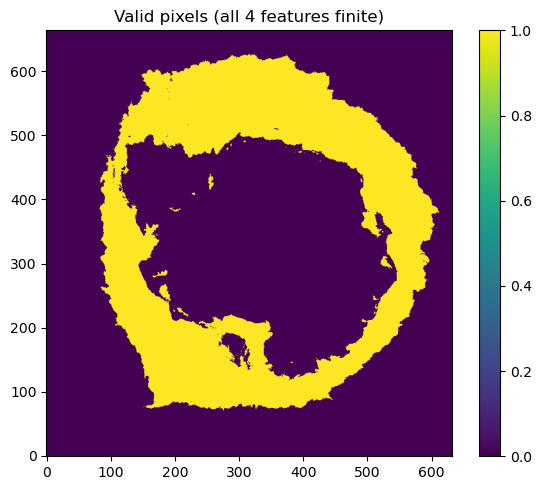

In [5]:
import numpy as np
import matplotlib.pyplot as plt

mask = np.isfinite(feat).all("feat")  # True if all 4 features are finite
plt.figure(figsize=(6,5))
plt.imshow(mask, origin="lower")
plt.title("Valid pixels (all 4 features finite)")
plt.colorbar()
plt.tight_layout()


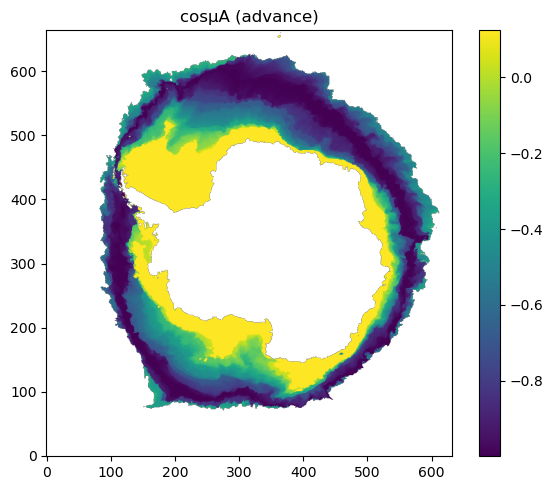

In [6]:
plt.figure(figsize=(6,5))
plt.imshow(feat.sel(feat="cosμA"), origin="lower")
plt.title("cosμA (advance)")
plt.colorbar()
plt.tight_layout()


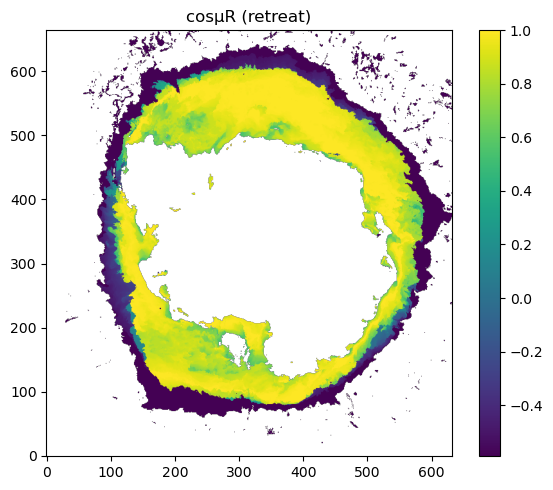

In [7]:
plt.figure(figsize=(6,5))
plt.imshow(feat.sel(feat="cosμR"), origin="lower")
plt.title("cosμR (retreat)")
plt.colorbar()
plt.tight_layout()


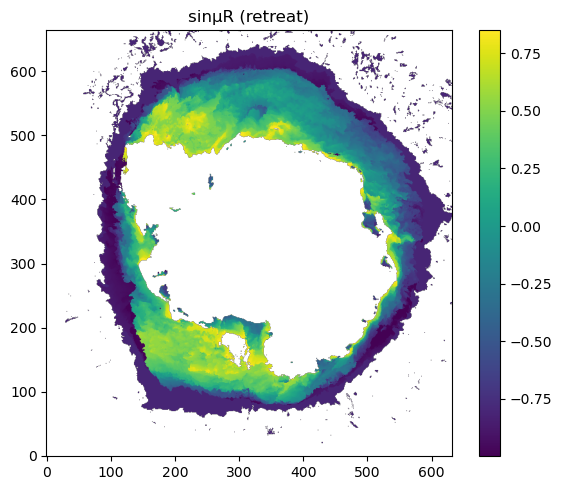

In [8]:
plt.figure(figsize=(6,5))
plt.imshow(feat.sel(feat="sinμR"), origin="lower")
plt.title("sinμR (retreat)")
plt.colorbar()
plt.tight_layout()


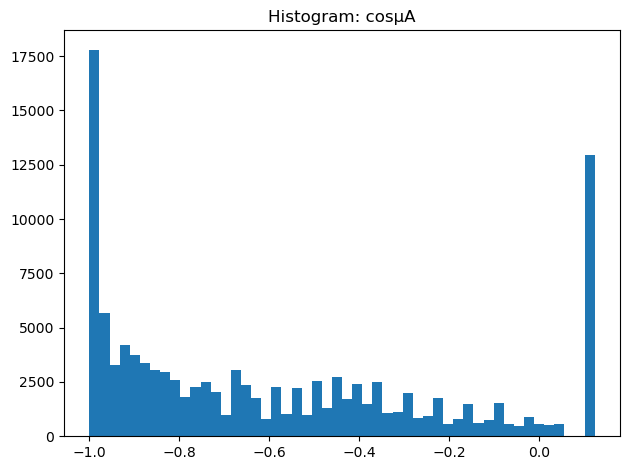

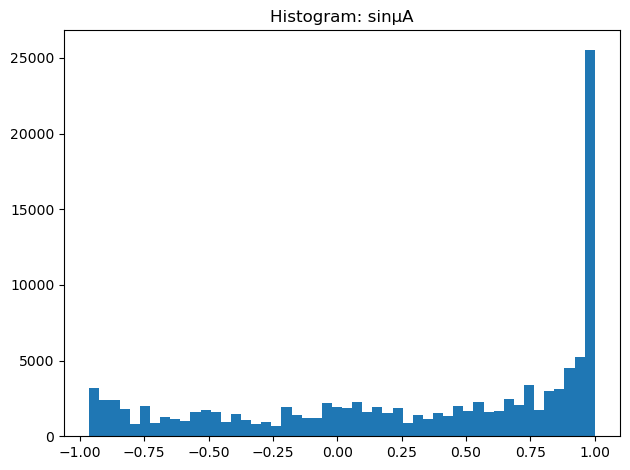

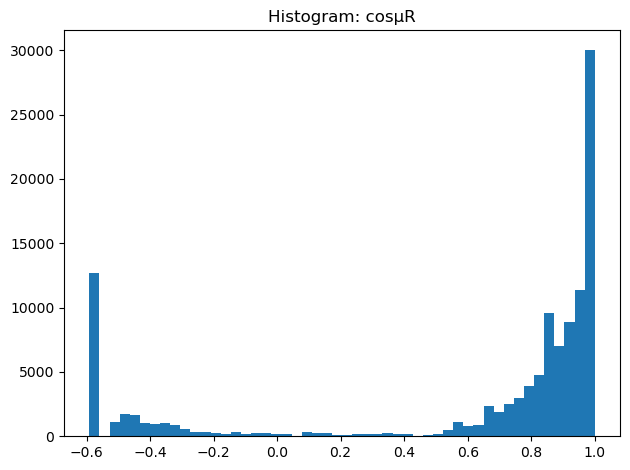

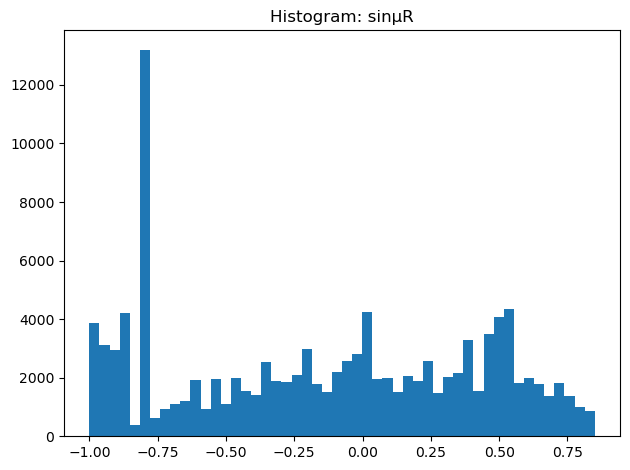

In [9]:
vals = feat.values.reshape(-1, 4)
vals = vals[np.isfinite(vals).all(axis=1)]

import matplotlib.pyplot as plt

plt.figure()
plt.hist(vals[:,0], bins=50)  # cosμA
plt.title("Histogram: cosμA")
plt.tight_layout()

plt.figure()
plt.hist(vals[:,1], bins=50)  # sinμA
plt.title("Histogram: sinμA")
plt.tight_layout()

plt.figure()
plt.hist(vals[:,2], bins=50)  # cosμR
plt.title("Histogram: cosμR")
plt.tight_layout()

plt.figure()
plt.hist(vals[:,3], bins=50)  # sinμR
plt.title("Histogram: sinμR")
plt.tight_layout()


In [11]:
# Cell 5 — Build (N,4) the simple NumPy way

import numpy as np

# feat has shape (y, x, 4)
vals = feat.values                      # (Y, X, 4)
Y, Xn, F = vals.shape
assert F == 4, f"Expected 4 features, got {F}"

# Flatten the grid to rows of 4 features
flat = vals.reshape(Y*Xn, F)            # (Y*X, 4)

# Valid rows = all four features are finite
valid_rows = np.isfinite(flat).all(axis=1)   # (Y*X,)

# Feature matrix for ML
X = flat[valid_rows]                    # (N, 4)

# Mask for mapping back to (y,x)
mask_np = valid_rows.reshape(Y, Xn)     # (y, x)

# Helper to put vectors back on the grid
def grid_from_vector(vec, mask_boolean):
    out = np.full(mask_boolean.shape, np.nan, dtype=float)
    out[mask_boolean] = vec
    return out

print("X shape (N,4):", X.shape)
print("First 3 rows of X:\n", X[:3])
print("Valid pixel fraction:", mask_np.mean())
print("Grid shape:", (Y, Xn))



X shape (N,4): (115333, 4)
First 3 rows of X:
 [[-0.28435919 -0.95871782 -0.59126144 -0.80647995]
 [-0.28435919 -0.95871782 -0.59126144 -0.80647995]
 [-0.30081981 -0.953681   -0.59126144 -0.80647995]]
Valid pixel fraction: 0.27483271694372424
Grid shape: (664, 632)
